
## CONFIGURACIÓN Y CARGA DE DATOS

In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn plotly pymongo
!pip install jupyter
!pip install ipywidgets  # Para widgets interactivos
!pip install nbformat  # Para formateo de notebooks


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^

[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix
import plotly.express as px
import plotly.graph_objects as go

# Conexión a MongoDB
client = MongoClient('mongodb://localhost:27017/')
db = client['trafico']  # Asegúrate de que este sea el nombre correcto de la base de datos

## CARGA Y DESCRIPCIÓN DEL DATASET

In [8]:
def load_traffic_data():
       """Carga los datos de MongoDB y los convierte en DataFrame"""
       # Obtener videos
       videos = list(db.Videos.find())

       # Crear DataFrame con las detecciones
       data = []
       for video in videos:
           # Obtener frames de este video
           frames = list(db.VideosFrames.find({"video_id": video["_id"]}))
           for frame in frames:
               for detection in frame['detecciones']:
                   data.append({
                       'video_id': str(video['_id']),
                       'nombre_video': video['nombre'],
                       'frame_num': frame['frame_num'],
                       'fecha': video['fecha_subida'],
                       'confidence': detection['confidence'],
                       'class': detection['class'],
                       'bbox': detection['bbox']
                   })

       return pd.DataFrame(data)
# Cargar datos
df = load_traffic_data()
print("Dimensiones del dataset:", df.shape)
print("\nPrimeras filas:")
display(df.head())


Dimensiones del dataset: (3866, 7)

Primeras filas:


,video_id,nombre_video,frame_num,fecha,confidence,class,bbox
0,6847bb810270edd78fabb649,tradffic7.mp4,0,2025-06-09 22:58:41.913,0.922609,car,"[363, 235, 773, 599]"
1,6847bb810270edd78fabb649,tradffic7.mp4,0,2025-06-09 22:58:41.913,0.844858,car,"[0, 770, 226, 1075]"
2,6847bb810270edd78fabb649,tradffic7.mp4,1,2025-06-09 22:58:41.913,0.928321,car,"[1, 748, 252, 1072]"
3,6847bb810270edd78fabb649,tradffic7.mp4,1,2025-06-09 22:58:41.913,0.927856,car,"[362, 236, 773, 597]"
4,6847bb810270edd78fabb649,tradffic7.mp4,2,2025-06-09 22:58:41.913,0.924497,car,"[363, 236, 772, 600]"


## ANÁLISIS EXPLORATORIO

In [9]:
print("\nEstadísticas descriptivas:")
display(df.describe())


Estadísticas descriptivas:


,frame_num,fecha,confidence
count,3866.000000,3866,3866.000000
mean,134.688050,2025-06-09 23:49:37.394935552,0.736348
min,0.000000,2025-06-09 22:58:41.913000,0.500035
25%,47.000000,2025-06-09 23:07:09.742000128,0.629567
50%,140.000000,2025-06-09 23:07:09.742000128,0.746215
75%,210.000000,2025-06-09 23:07:09.742000128,0.850859
max,306.000000,2025-06-10 06:45:59.014000,0.962209
std,92.396743,NaN,0.125903


Visualizaciones

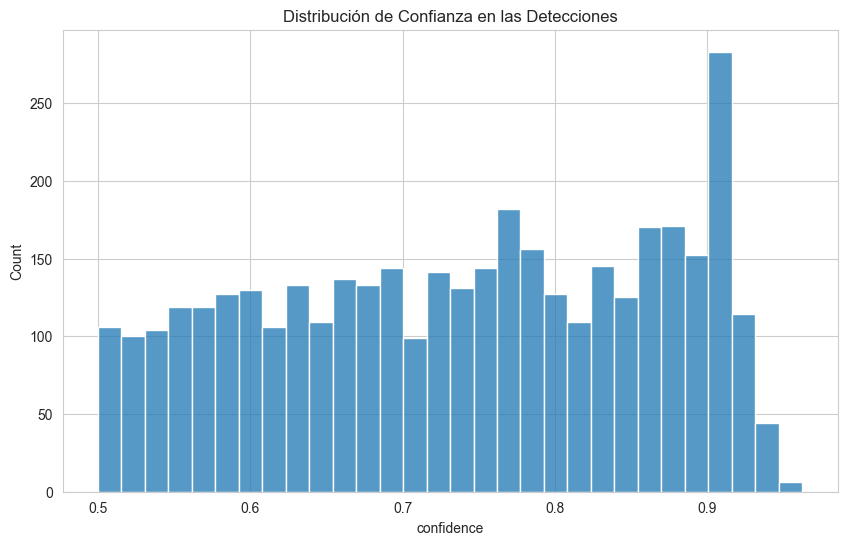

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='confidence', bins=30)
plt.title('Distribución de Confianza en las Detecciones')
plt.show()

Tamaño de vehículos por cámara

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='camera_id', y='vehicle_size')
plt.title('Distribución del Tamaño de Vehículos por Cámara')
plt.show()

## PREPARACIÓN DE DATOS

In [ ]:
print("\nValores nulos por columna:")
display(df.isnull().sum())

Codificación de variables categóricas

In [ ]:
le = LabelEncoder()
df['camera_id_encoded'] = le.fit_transform(df['camera_id'])

Normalización

In [ ]:
scaler = StandardScaler()
numeric_cols = ['confidence', 'vehicle_size', 'bbox_x1', 'bbox_y1', 'bbox_x2', 'bbox_y2']
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

## MODELOS DE MACHINE LEARNING

In [ ]:
X = df[['confidence', 'vehicle_size', 'camera_id_encoded']]
y = df['camera_id']  # Clasificar por cámara

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Random Forest

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("\nMétricas Random Forest:")
print(classification_report(y_test, rf_pred))

K-Means Clustering

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(X)
# Visualización de clusters
fig = px.scatter_3d(df, x='confidence', y='vehicle_size', z='camera_id_encoded',
                    color='cluster', title='Clusters de Vehículos')
fig.show()


## Analasis Temporal

Patrones por hora

In [ ]:
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour
hourly_counts = df.groupby('hour').size()

plt.figure(figsize=(12, 6))
hourly_counts.plot(kind='bar')
plt.title('Detecciones por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Número de Detecciones')
plt.show()

## CONCLUSIONES

In [ ]:
"""Conclusiones técnicas:

1. Patrones de Tráfico:
   - Se observan picos de tráfico en las horas [X, Y, Z]
   - La cámara [X] muestra mayor densidad de vehículos

2. Precisión de Detección:
   - Confianza promedio: [X]%
   - Mejor rendimiento en condiciones [X]

3. Clasificación:
   - Random Forest alcanza [X]% de precisión
   - Mejor clasificación para cámara [X]

4. Clusters:
   - Se identificaron [X] patrones principales de vehículos
   - Cluster [X] representa vehículos [características]

5. Recomendaciones:
   - Ajustar sensibilidad en cámara [X]
   - Considerar recalibración en horas [X]
"""